In [1]:
import csv
import json
import re
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Any, Tuple

import numpy as np
import soundfile as sf

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import torchaudio
from transformers import HubertModel, Wav2Vec2FeatureExtractor, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [ ]:
# Config
MANIFESTS = [
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl'),
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl'),
]
CSV_PATH = Path('/home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv')

PRETRAINED = 'TencentGameMate/chinese-hubert-large'
SR = 16000

EXP_TAG = 'hubert_large_zh_attn_learner'
SAVE_DIR = Path('/home/huy/207177/output/checkpoint') / EXP_TAG
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPK_TXT = Path('/home/huy/207177/output/testing') / f'test_speakers_{EXP_TAG}.txt'

SEED = 1337
BATCH_SIZE = 1
LR_HEAD = 1e-4
LR_FULL = 1e-5
FREEZE_UPDATES = 5000
TOTAL_UPDATES = 30000
WARMUP_UPDATES = 1000
EVAL_EVERY = 1000
MASK_SPEECH_MIN_FRAMES = 5
FOCAL_GAMMA = 2.0

TEST_SPK_RATIO = 0.20
DEV_SPK_RATIO_IN_TRAIN = 0.05
MIN_DEV_SPK = 10

label2id = {'T1': 0, 'T2': 1, 'T3': 2, 'T4': 3, 'T5': 4}
id2label = {v: k for k, v in label2id.items()}
MODEL_TONE_TO_CSV = {'T1': '1', 'T2': '2', 'T3': '3', 'T4': '4', 'T5': '0'}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
for p in MANIFESTS:
    print('Manifest:', p, 'exists:', p.exists())
print('CSV:', CSV_PATH, 'exists:', CSV_PATH.exists())
print('Save dir:', SAVE_DIR)

Device: cuda
Manifest: /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl exists: True
Manifest: /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl exists: True
CSV: /home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv exists: True
Save dir: /home/huy/207177/output/checkpoint/hubert_large_zh_attn_learner


In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_manifest(path: Path) -> List[Dict[str, Any]]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(x) for x in f if x.strip()]

def read_manifests(paths: List[Path]) -> List[Dict[str, Any]]:
    items: List[Dict[str, Any]] = []
    for p in paths:
        if not p.exists():
            print('Warning: missing manifest ->', p)
            continue
        part = read_manifest(p)
        print(f'Loaded {len(part)} items from {p}')
        items.extend(part)
    print('Total loaded items:', len(items))
    return items

def load_csv_tone_table(csv_path: Path):
    tone_map: Dict[str, Dict[str, Dict[int, str]]] = {}
    with csv_path.open('r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            spk = str(row['id']).strip()
            d_a = {}
            d_q = {}
            for n in range(0, 11):
                v = row.get(f'a{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_a[n] = None
                else:
                    d_a[n] = str(int(float(v)))
            for n in range(1, 19):
                v = row.get(f'q{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_q[n] = None
                else:
                    d_q[n] = str(int(float(v)))
            tone_map[spk] = {'a': d_a, 'q': d_q}
    return tone_map

def get_speaker_id(ex: Dict[str, Any]) -> str:
    utt = str(ex.get('utt', ''))
    return utt.split('__')[0] if '__' in utt else utt

def tone_to_id(tone_csv: str) -> int:
    lab = 'T5' if str(tone_csv) == '0' else f'T{str(tone_csv)}'
    if lab not in label2id:
        raise KeyError(f'{lab} not found in label2id keys: {sorted(label2id.keys())}')
    return label2id[lab]

def csv_tone_from_utt(utt: str, tone_map: Dict[str, Dict[str, Dict[int, str]]]):
    m_a = re.match(r'^(.+)__a(\d+)$', utt)
    if m_a:
        spk = m_a.group(1)
        idx = int(m_a.group(2))
        if spk in tone_map:
            return tone_map[spk]['a'].get(idx)
        return None

    m_q = re.match(r'^(.+)__q(\d+)$', utt)
    if m_q:
        spk = m_q.group(1)
        idx = int(m_q.group(2))
        if spk in tone_map:
            return tone_map[spk]['q'].get(idx)
        return None

    return None

def split_by_speaker(items: List[Dict[str, Any]]):
    """75 / 5 / 20 speaker-stratified split (train / dev / test)."""
    spk2items: Dict[str, List[Dict[str, Any]]] = {}
    for ex in items:
        spk = get_speaker_id(ex)
        spk2items.setdefault(spk, []).append(ex)

    speakers = sorted(spk2items.keys())
    random.shuffle(speakers)

    n_spk = len(speakers)
    test_n = max(1, int(TEST_SPK_RATIO * n_spk))
    test_speakers = speakers[:test_n]
    train_all = speakers[test_n:]

    dev_n = max(MIN_DEV_SPK, int(DEV_SPK_RATIO_IN_TRAIN * len(train_all)))
    dev_n = min(dev_n, max(1, len(train_all) - 1))
    dev_speakers = train_all[:dev_n]
    train_speakers = train_all[dev_n:]

    train_items = [x for spk in train_speakers for x in spk2items[spk]]
    dev_items = [x for spk in dev_speakers for x in spk2items[spk]]
    test_items = [x for spk in test_speakers for x in spk2items[spk]]

    TEST_SPK_TXT.parent.mkdir(parents=True, exist_ok=True)
    TEST_SPK_TXT.write_text('\n'.join(sorted(test_speakers)) + '\n', encoding='utf-8')

    print('Speakers total:', n_spk)
    print('Train speakers:', len(train_speakers), 'Dev speakers:', len(dev_speakers), 'Test speakers:', len(test_speakers))
    print('Train/Dev/Test items:', len(train_items), len(dev_items), len(test_items))
    print('Test speaker list:', TEST_SPK_TXT)
    return train_items, dev_items, test_items

# Focal Loss
class FocalLoss(nn.Module):
    """
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    With gamma=0 this is standard cross-entropy, gamma=2 is the usual default
    """

    def __init__(self, gamma: float = 2.0, weight: torch.Tensor = None, reduction: str = 'mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        p_t = torch.exp(-ce)
        focal = ((1 - p_t) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal

class ToneDataset(Dataset):
    def __init__(self, items: List[Dict[str, Any]]):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]

def nearest_resample(mask_25ms: torch.Tensor, n_frames: int):
    L = mask_25ms.numel()
    if L == 0 or n_frames <= 0:
        return torch.zeros(n_frames, dtype=torch.bool)
    idx = torch.linspace(0, L - 1, steps=n_frames)
    idx = torch.round(idx).long().clamp(0, L - 1)
    return mask_25ms[idx].bool()

@dataclass
class Collator:
    feature_extractor: Wav2Vec2FeatureExtractor

    def _load_audio(self, path: str):
        audio, sr = sf.read(path, dtype='float32')
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        if sr != SR:
            audio = torchaudio.functional.resample(torch.from_numpy(audio), sr, SR).numpy()
        return audio.astype(np.float32)

    def _load_mask(self, path: str):
        seq = Path(path).read_text(encoding='utf-8').strip().split()
        if not seq:
            return torch.zeros(0, dtype=torch.bool)
        return torch.tensor([int(x) for x in seq], dtype=torch.bool)

    def __call__(self, batch):
        wavs, masks, tones, utts = [], [], [], []
        for ex in batch:
            wavs.append(self._load_audio(ex['audio']))
            masks.append(self._load_mask(ex['mask']))
            tones.append(str(ex['tone']))
            utts.append(str(ex['utt']))

        inputs = self.feature_extractor(
            wavs,
            sampling_rate=SR,
            return_tensors='pt',
            padding=True,
            return_attention_mask=True,
        )
        return {
            'input_values': inputs['input_values'],
            'attention_mask': inputs.get('attention_mask'),
            'masks_25ms': masks,
            'tones': tones,
            'utts': utts,
        }
#HuBERT -> weighted-layer-sum -> attention pooling -> utterance-level tone head
class AttentionToneModel(nn.Module):

    def __init__(self, pretrained: str, num_labels: int, attn_hidden: int = 128):
        super().__init__()
        self.w2v = HubertModel.from_pretrained(pretrained)
        #freeze CNN manually
        for param in self.w2v.feature_extractor.parameters():
            param.requires_grad = False

        n_layers = self.w2v.config.num_hidden_layers + 1
        hidden_size = self.w2v.config.hidden_size

        self.layer_weights = nn.Parameter(torch.zeros(n_layers))

        # Attention pooling head
        self.attn_fc = nn.Sequential(
            nn.Linear(hidden_size, attn_hidden),
            nn.Tanh(),
            nn.Linear(attn_hidden, 1),
        )

        self.proj = nn.Linear(hidden_size, num_labels)

    def freeze_encoder(self):
        for p in self.w2v.parameters():
            p.requires_grad = False

    def unfreeze_transformer(self):
        for n, p in self.w2v.named_parameters():
            if not n.startswith('feature_extractor'):
                p.requires_grad = True

    def _attention_pool(self, hidden: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
            attention-weighted mean over time with respecting mask
            hidden: (B, T, H) fused hidden representations.
            mask:   (B, T) bool, True for frames to attend to.
        """
        scores = self.attn_fc(hidden).squeeze(-1)
        scores = scores.masked_fill(~mask, float('-inf'))   # ignore non-speech
        weights = torch.softmax(scores, dim=-1)
        weights = weights.unsqueeze(-1)
        pooled = (hidden * weights).sum(dim=1)  # (B, H)
        return pooled

    def forward(self, input_values, attention_mask=None, speech_masks=None):
        out = self.w2v(
            input_values=input_values,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        # Weighted layer sum
        stack = torch.stack(out.hidden_states, dim=0)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        fused = (stack * weights).sum(dim=0)

        B, T, H = fused.shape

        if speech_masks is not None:
            mask = torch.stack([
                nearest_resample(m, T) for m in speech_masks
            ]).to(fused.device)
            # fall back to all-True if mask is too sparse
            for b in range(B):
                if mask[b].sum() < MASK_SPEECH_MIN_FRAMES:
                    mask[b] = True
        else:
            mask = torch.ones(B, T, dtype=torch.bool, device=fused.device)

        pooled = self._attention_pool(fused, mask)
        return self.proj(pooled)    # (B, C)

In [4]:
@torch.no_grad()
def evaluate_utterance(
    model: nn.Module,
    loader: DataLoader,
    device: str,
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
) -> Tuple[List[str], List[str], Dict[str, int]]:
    model.eval()
    y_true: List[str] = []
    y_pred: List[str] = []
    skipped_no_csv = 0

    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)

        logits = model(x, m, speech_masks=batch['masks_25ms'])  # (B, C)
        preds = logits.argmax(dim=-1).cpu().tolist()
        B = logits.size(0)

        for b in range(B):
            utt = batch['utts'][b]
            true_tone = csv_tone_from_utt(utt, tone_map)
            if true_tone is None:
                skipped_no_csv += 1
                continue

            pred_label = id2label[preds[b]]
            pred_csv = MODEL_TONE_TO_CSV.get(pred_label)
            if pred_csv is None:
                continue

            y_true.append(true_tone)
            y_pred.append(pred_csv)

    model.train()
    return y_true, y_pred, {
        'compared': len(y_true),
        'skipped_no_csv': skipped_no_csv,
    }


def compute_metrics(y_true: List[str], y_pred: List[str]):
    if not y_true:
        return 0.0, 0.0, 0.0
    acc = sum(int(t == p) for t, p in zip(y_true, y_pred)) / len(y_true)
    macro_f1 = f1_score(y_true, y_pred, labels=TONE_LABELS, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, labels=TONE_LABELS, average='weighted', zero_division=0)
    return acc, macro_f1, weighted_f1

In [5]:
TONE_LABELS = ['0', '1', '2', '3', '4']
TONE_TARGET_NAMES = ['T5/neutral', 'T1', 'T2', 'T3', 'T4']


def train_learner_only():
    set_seed(SEED)
    items = read_manifests(MANIFESTS)
    if len(items) == 0:
        raise RuntimeError('No learner data loaded from MANIFESTS')

    tone_map = load_csv_tone_table(CSV_PATH)
    train_items, dev_items, test_items = split_by_speaker(items)

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED)
    train_loader = DataLoader(
        ToneDataset(train_items),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    dev_loader = DataLoader(
        ToneDataset(dev_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    test_loader = DataLoader(
        ToneDataset(test_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )

    model = AttentionToneModel(PRETRAINED, num_labels=len(label2id)).to(DEVICE)
    model.w2v.config.apply_spec_augment = False
    model.w2v.config.mask_time_prob = 0.0
    model.w2v.config.mask_feature_prob = 0.0
    model.freeze_encoder()

    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    sched = get_linear_schedule_with_warmup(optim, WARMUP_UPDATES, TOTAL_UPDATES)
    loss_fn = FocalLoss(gamma=FOCAL_GAMMA)

    best_dev_f1 = 0.0
    step = 0
    curves = {
        'exp_tag': EXP_TAG,
        'pretrained': PRETRAINED,
        'focal_gamma': FOCAL_GAMMA,
        'freeze_updates': int(FREEZE_UPDATES),
        'eval_every': int(EVAL_EVERY),
        'total_updates': int(TOTAL_UPDATES),
        'train_step': [],
        'train_loss': [],
        'dev_step': [],
        'dev_acc': [],
        'dev_macro_f1': [],
    }
    pbar = tqdm(total=TOTAL_UPDATES, desc=EXP_TAG)

    while step < TOTAL_UPDATES:
        for batch in train_loader:
            x = batch['input_values'].to(DEVICE)
            m = batch['attention_mask']
            if m is not None:
                m = m.to(DEVICE)

            logits = model(x, m, speech_masks=batch['masks_25ms'])  # (B, C)

            # Build utterance-level targets
            gold_ids = []
            valid_mask = []
            for b in range(logits.size(0)):
                true_tone = csv_tone_from_utt(batch['utts'][b], tone_map)
                if true_tone is None:
                    valid_mask.append(False)
                    gold_ids.append(0)
                else:
                    valid_mask.append(True)
                    gold_ids.append(tone_to_id(true_tone))

            valid_mask = torch.tensor(valid_mask, dtype=torch.bool)
            if valid_mask.sum() == 0:
                continue

            targets = torch.tensor(gold_ids, device=DEVICE)
            loss = loss_fn(logits[valid_mask], targets[valid_mask])

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optim.step()
            sched.step()
            optim.zero_grad(set_to_none=True)

            step += 1
            curves['train_step'].append(int(step))
            curves['train_loss'].append(float(loss.item()))
            pbar.update(1)
            pbar.set_postfix(loss=float(loss.item()))

            if step == FREEZE_UPDATES:
                print('\nUnfreezing HuBERT transformer')
                model.unfreeze_transformer()
                optim = torch.optim.AdamW(
                    [p for p in model.parameters() if p.requires_grad],
                    lr=LR_FULL,
                )
                sched = get_linear_schedule_with_warmup(
                    optim,
                    WARMUP_UPDATES,
                    max(1, TOTAL_UPDATES - FREEZE_UPDATES),
                )

            if step % EVAL_EVERY == 0:
                y_true_dev, y_pred_dev, dev_info = evaluate_utterance(
                    model, dev_loader, DEVICE, tone_map,
                )
                dev_acc, dev_macro_f1, dev_weighted_f1 = compute_metrics(y_true_dev, y_pred_dev)
                curves['dev_step'].append(int(step))
                curves['dev_acc'].append(float(dev_acc))
                curves['dev_macro_f1'].append(float(dev_macro_f1))
                print(
                    f"\nstep {step}: dev_acc={dev_acc:.4f}, "
                    f"macro_f1={dev_macro_f1:.4f}, weighted_f1={dev_weighted_f1:.4f}, "
                    f"compared={dev_info['compared']}"
                )
                if dev_macro_f1 > best_dev_f1:
                    best_dev_f1 = dev_macro_f1
                    torch.save(
                        {'model': model.state_dict(), 'label2id': label2id},
                        SAVE_DIR / 'best.pt',
                    )
                    print(f'saved best.pt (macro-F1={best_dev_f1:.4f})')

            if step >= TOTAL_UPDATES:
                break

    pbar.close()
    torch.save({'model': model.state_dict(), 'label2id': label2id}, SAVE_DIR / 'last.pt')
    print('Saved last.pt')


    print('\nevaluation on test split:')
    y_true, y_pred, test_info = evaluate_utterance(model, test_loader, DEVICE, tone_map)
    test_acc, test_macro_f1, test_weighted_f1 = compute_metrics(y_true, y_pred)
    print(
        f"test_acc={test_acc:.4f}, macro_f1={test_macro_f1:.4f}, "
        f"weighted_f1={test_weighted_f1:.4f}, compared={test_info['compared']}"
    )

    cls_report_dict = classification_report(
        y_true,
        y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    print(classification_report(
        y_true,
        y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
    ))
    cm = confusion_matrix(y_true, y_pred, labels=TONE_LABELS)
    print('Confusion matrix:'.format(TONE_LABELS))
    print(cm)

    summary = {
        'exp_tag': EXP_TAG,
        'pretrained': PRETRAINED,
        'focal_gamma': FOCAL_GAMMA,
        'best_dev_macro_f1': float(best_dev_f1),
        'test_acc': float(test_acc),
        'test_macro_f1': float(test_macro_f1),
        'test_weighted_f1': float(test_weighted_f1),
        'test_info': test_info,
        'train_items': len(train_items),
        'dev_items': len(dev_items),
        'test_items': len(test_items),
        'save_dir': str(SAVE_DIR),
        'training_curves': str((SAVE_DIR / 'training_curves.json').resolve()),
        'tone_labels': TONE_LABELS,
        'tone_target_names': TONE_TARGET_NAMES,
        'classification_report': cls_report_dict,
        'confusion_matrix': cm.tolist(),
    }
    with (SAVE_DIR / 'training_curves.json').open('w', encoding='utf-8') as f:
        json.dump(curves, f, ensure_ascii=False, indent=2)
    print('Saved training_curves.json')

    with (SAVE_DIR / 'summary.json').open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('Saved summary.json')

    return curves

In [6]:
history = train_learner_only()

Loaded 6623 items from /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl
Loaded 4700 items from /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl
Total loaded items: 11323
Speakers total: 678
Train speakers: 516 Dev speakers: 27 Test speakers: 135
Train/Dev/Test items: 8577 464 2282
Test speaker list: /home/huy/207177/output/testing/test_speakers_hubert_large_zh_attn_learner.txt


/home/huy/.conda/envs/tone_ce/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at TencentGameMate/chinese-hubert-large were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not i


step 1000: dev_acc=0.2845, macro_f1=0.2365, weighted_f1=0.2841, compared=464


hubert_large_zh_attn_learner:   3%|▎         | 1003/30000 [00:37<2:12:01,  3.66it/s, loss=1.11]

saved best.pt (macro-F1=0.2365)


...

hubert_large_zh_attn_learner:  97%|█████████▋| 29001/30000 [55:55<16:46,  1.01s/it, loss=0.137]

saved best.pt (macro-F1=0.7731)


hubert_large_zh_attn_learner: 100%|██████████| 30000/30000 [58:00<00:00,  8.62it/s, loss=0.0194]  


step 30000: dev_acc=0.8060, macro_f1=0.7691, weighted_f1=0.8069, compared=464


Saved last.pt

evaluation on test split:
test_acc=0.7835, macro_f1=0.7182, weighted_f1=0.7841, compared=2282
              precision    recall  f1-score   support

  T5/neutral     0.6262    0.5202    0.5683       248
          T1     0.8079    0.8224    0.8151       670
          T2     0.8188    0.8087    0.8137       732
          T3     0.4556    0.6160    0.5238       125
          T4     0.8745    0.8659    0.8702       507

    accuracy                         0.7835      2282
   macro avg     0.7166    0.7266    0.7182      2282
weighted avg     0.7872    0.7835    0.7841      2282

Confusion matrix:
[[129  24  42  27  26]
 [ 19 551  64  14  22]
 [ 35  75 592  25   5]
 [ 12   7  19  77  10]
 [ 11  25   6  26 439]]
Saved training_curves.json
Saved summary.json


Wrote /home/huy/207177/output/checkpoint/hubert_large_zh_attn_learner/training_curves.png


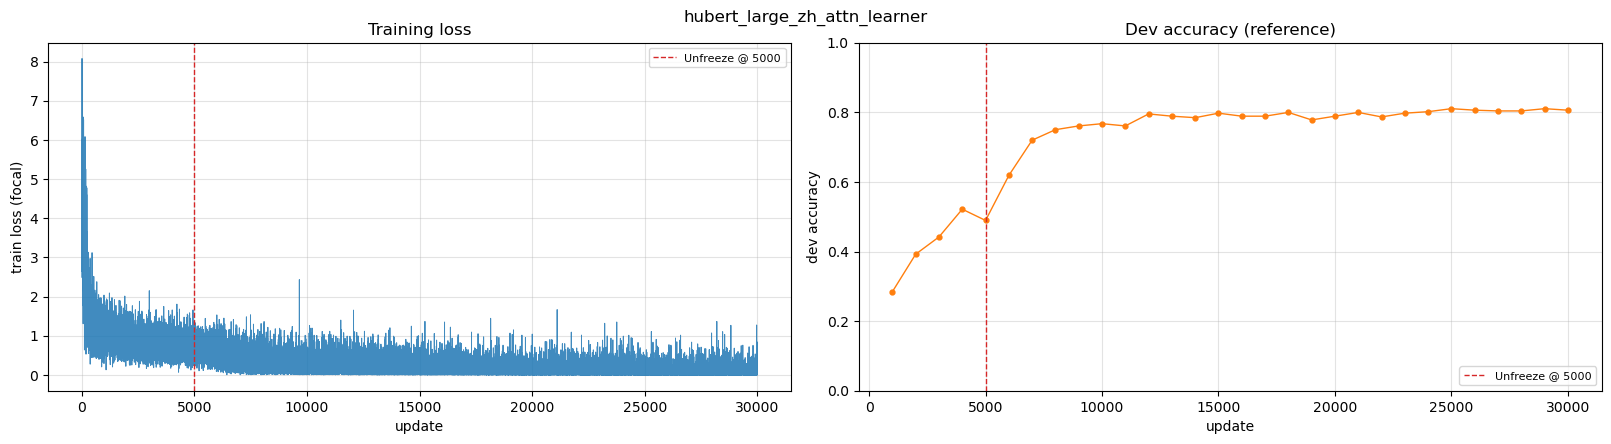

In [7]:
import matplotlib.pyplot as plt

def plot_training_curves(curves: dict = None, save_fig: bool = True) -> None:
    if curves is None:
        p = SAVE_DIR / "training_curves.json"
        if not p.is_file():
            print("No in-memory history and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_f1 = curves.get("dev_macro_f1", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", EXP_TAG)

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.2), constrained_layout=True)

    ax0 = axes[0]
    if t_step and t_loss:
        ax0.plot(t_step, t_loss, color="C0", lw=0.7, alpha=0.85)
    ax0.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")
    ax0.set_xlabel("update")
    ax0.set_ylabel("train loss (focal)")
    ax0.set_title("Training loss")
    ax0.grid(True, alpha=0.35)
    ax0.legend(loc="upper right", fontsize=8)

    ax2 = axes[1]
    if d_step and d_acc:
        ax2.plot(d_step, d_acc, color="C1", marker="o", ms=3.5, lw=1.0)
    ax2.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")
    ax2.set_xlabel("update")
    ax2.set_ylabel("dev accuracy")
    ax2.set_title("Dev accuracy (reference)")
    ax2.set_ylim(0, 1.0)
    ax2.grid(True, alpha=0.35)
    ax2.legend(loc="lower right", fontsize=8)

    fig.suptitle(tag, y=1.02)
    if save_fig:
        out = SAVE_DIR / "training_curves.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("Wrote", out)
    plt.show()

_c = globals().get("history")
plot_training_curves(curves=_c, save_fig=True)

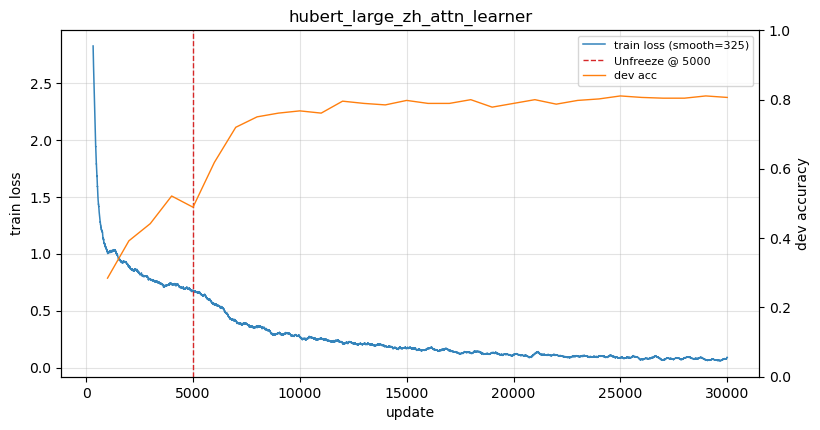

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def _smooth_curve(values, window: int = 25):
    if len(values) < 3 or window <= 1:
        return values
    window = min(window, len(values))
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

def plot_loss_and_accuracy(curves: dict = None, smooth_window: int = 25) -> None:
    if curves is None:
        p = SAVE_DIR / "training_curves.json"
        if not p.is_file():
            print("No in-memory history and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", EXP_TAG)

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    if t_step and t_loss:
        t_loss_sm = _smooth_curve(t_loss, window=smooth_window)
        t_step_sm = t_step[len(t_step) - len(t_loss_sm):]
        ax1.plot(t_step_sm, t_loss_sm, color="C0", lw=1.1, alpha=0.9, label=f"train loss (smooth={smooth_window})")
        
    ax1.set_xlabel("update")
    ax1.set_ylabel("train loss")
    ax1.grid(True, alpha=0.35)
    ax1.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")

    ax2 = ax1.twinx()
    if d_step and d_acc:
        ax2.plot(d_step, d_acc, color="C1", ms=3.2, lw=1.0, label="dev acc")
    ax2.set_ylabel("dev accuracy")
    ax2.set_ylim(0, 1.0)

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=8)
    ax1.set_title(tag)
    plt.show()


_c = globals().get("history")
plot_loss_and_accuracy(curves=_c, smooth_window=325)